In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph ,START ,END
from langchain_huggingface import HuggingFacePipeline , ChatHuggingFace
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

In [2]:
LOCAL_MODEL_PATH = r"C:\Users\dell\.cache\huggingface\hub\models--TinyLlama--TinyLlama-1.1B-Chat-v1.0\snapshots\fe8a4ea1ffedaf415f4da2f062534de366a451e6"

tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_PATH)

model = AutoModelForCausalLM.from_pretrained(
    LOCAL_MODEL_PATH,
    torch_dtype="auto"
)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256,
    do_sample=True,
    temperature=0.7
)

llm = HuggingFacePipeline(pipeline=pipe)
model = ChatHuggingFace(llm=llm)

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cpu


In [3]:
class chain_state(TypedDict):
    topic : str
    outline : str
    contain : str

In [5]:
def create_outline(state:chain_state) -> chain_state:
    topic = state["topic"]
    prompt = f"create ouline for a {topic}"
    outline = model.invoke(prompt)
    state["outline"] = outline
    return state

In [6]:
def create_contain(state:chain_state) -> chain_state:
    topic = state["topic"]
    outline = state["outline"]
    prompt = f"generate description for {topic} by using following {outline}"
    contain = model.invoke(prompt)
    state["contain"] = contain
    return state

In [8]:
graph = StateGraph(chain_state)

graph.add_node("create_outline",create_outline)
graph.add_node("create_contain",create_contain)

graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_contain")
graph.add_edge("create_contain",END)

workflow = graph.compile()


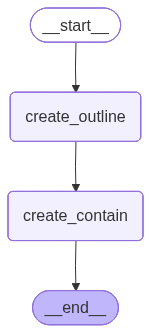

In [9]:
workflow

In [10]:
input_state = {"topic":"cricket"}
final_state = workflow.invoke(input_state)
print(final_state)

{'topic': 'cricket', 'outline': AIMessage(content="<|user|>\ncreate ouline for a cricket</s>\n<|assistant|>\nOur team is excited to announce the launch of our new online course on cricket!\n\nThis course is designed for anyone who wants to learn more about the sport of cricket. Whether you're a complete beginner or a seasoned cricket fan, this course will provide you with a comprehensive overview of the rules, history, and techniques of the game.\n\nHere's a rundown of what you'll learn:\n\n1. Introduction to Cricket: This section will give you a brief overview of the sport, including its origins, rules, and key players.\n\n2. The Ball: This section will explore the different types of balls and their different properties.\n\n3. The Bat: This section will teach you the basics of the bat—how to use it, how to grip it, and how to swing it correctly.\n\n4. The Wicket: This section will discuss the wicket, including its construction, design, and how it's maintained.\n\n5. The Cricket Field: